In [19]:
import torch
import torch.nn as nn


device = torch.device("cpu")
if (torch.cuda.is_available()):
    device = torch.device("cuda")
if (torch.backends.mps.is_available()):
    device = torch.device("mps")

print('Using device:', device)

LEARNING_RATE = 0.0001
BATCH_SIZE = 256
NUM_EPOCHS = 100

Using device: mps


In [15]:
import numpy as np

train_data = np.load(
    "/Users/boo/Desktop/coding/Deep_Learning/Autoencoder_Python/Variational/data/matrix/chunk1_counts.npz")
row = torch.from_numpy(train_data['row'])
col = torch.from_numpy(train_data['col'])

values = train_data['data']
indices = np.vstack((row, col))

i = torch.LongTensor(indices)
v = torch.FloatTensor(values)
shape = train_data['shape']
torch_Data = torch.sparse_coo_tensor(i,v,torch.Size(shape)).to_dense()
#torch_train = torch.from_numpy(train_data)

data_loader = torch.utils.data.DataLoader(
    torch_Data, batch_size=BATCH_SIZE, shuffle=True)

print(torch_Data.shape)


torch.Size([60664, 285341])


In [20]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(torch_Data.shape[1], 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
        )
        self.z_mean = nn.Linear(64, 32)
        self.z_log_var = nn.Linear(64, 32)
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, torch_Data.shape[1]),
            nn.Sigmoid(),
        )

    def reparameterize(self, z_mu, z_log_var):
        esp = torch.randn(z_mu.shape[0], z_mu.shape[1]).to(device)
        z = z_mu + esp * torch.exp(z_log_var/2.)
        return z
    
    def encoding(self, x):
        x = self.encoder(x)
        z_mean,z_log_var = self.z_mean(x),self.z_log_var(x)
        encoded = self.reparameterize(z_mean,z_log_var)
        return encoded

    def forward(self,x):
        x = self.encoder(x)
        z_mean,z_log_var = self.z_mean(x),self.z_log_var(x)
        encoded = self.reparameterize(z_mean,z_log_var)
        decoded = self.decoder(encoded)
        return encoded, z_mean, z_log_var,decoded

In [21]:
model = VAE()
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [22]:
import torch.nn.functional as Functional

losses = []
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch_idx, features in enumerate(data_loader):
        features = features.to(device)

        encoded, z_mean, z_log_var, decoded = model(features)
        # sum over latent dimension
        kl_div = -0.5 * torch.sum(1 + z_log_var -
                                  z_mean**2 - torch.exp(z_log_var), axis=1)
        batchsize = kl_div.size(0)
        kl_div = torch.mean(kl_div)

        reconstruction_loss = Functional.mse_loss(
            decoded, features, reduction='none')  # sum over all pixels
        reconstruction_loss = reconstruction_loss.view(
            batchsize, -1).sum(axis=1)
        reconstruction_loss = reconstruction_loss.mean()

        loss = kl_div + reconstruction_loss
        total_loss += loss
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
    losses.append(total_loss/len(data_loader))
    if (epoch % 10 == 0 or epoch == NUM_EPOCHS-1):
        epoch = epoch+1 if epoch == NUM_EPOCHS-1 else epoch
        print("Epoch: %d, Loss: %f" % (epoch, total_loss / len(data_loader)))

Epoch: 0, Loss: 26891.083984
Epoch: 10, Loss: 8889.036133
Epoch: 20, Loss: 8363.566406
Epoch: 30, Loss: 8193.344727
Epoch: 40, Loss: 8121.335449
Epoch: 50, Loss: 8068.441895
Epoch: 60, Loss: 8020.118652
Epoch: 70, Loss: 7984.815918
Epoch: 80, Loss: 7964.025391
Epoch: 90, Loss: 7942.688477
Epoch: 100, Loss: 7925.012207


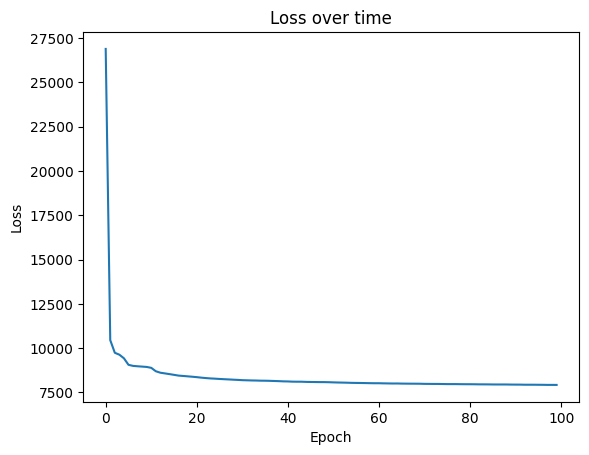

In [23]:
import matplotlib.pyplot as plt
# plot loss over time
losses_cpu = [loss.cpu().detach().numpy() for loss in losses]

plt.plot(losses_cpu)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over time')
plt.show()